# ECG Sliding Window Classification

Notebook này tập trung vào pipeline phân loại ECG theo cửa sổ trượt

## Nội dung
1. Setup & Libraries
2. Data Split theo record cố định
3. Label definitions & Load ECG từ MIT-BIH
4. Preprocessing + Feature Engineering
5. Build Sliding Window Dataset
6. Training & Evaluation (RF, ET, XGB)
7. So sánh cấu hình 4.5s vs 9s
8. EDA & Visualization kết quả
9. Confusion Matrix & nhận xét cuối



## 1. Setup & Libraries

Phần này import tất cả các thư viện cần thiết cho pipeline:
- **Data processing**: numpy, pandas, scipy
- **Signal processing**: wfdb (MIT-BIH), neurokit2 (ECG analysis)
- **Machine learning**: scikit-learn, xgboost, imblearn
- **Visualization**: matplotlib, seaborn
- **Utilities**: tqdm (progress bar), joblib (caching), pathlib

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import neurokit2 as nk

from tqdm import tqdm
from collections import Counter

from scipy.signal import butter, filtfilt, welch, iirnotch
from scipy.stats import skew, kurtosis

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import torch
import joblib
import os
from pathlib import Path

## 2. Data Split by Records

Phần này thiết lập tập `train/validation/test` theo danh sách record cố định để đảm bảo:
- Tái lập kết quả
- Không có overlap giữa các tập
- Đánh giá khách quan trên test set

In [27]:
# Test: 102-106 (5 records)
# Val: 200, 208, 232, 233, 234 (5 records)
# Train: remaining records

all_records = [
    "100","101","102","103","105","106","107","108","109",
    "111","112","113","114","115","116","117","118","119",
    "121","122","123","124",
    "200","201","202","203","205","207","208","209","210",
    "212","213","214","215","217","219","220","221","222",
    "223","228","230","231","232","233","234"
]

test_records = ["102", "103", "104", "105", "106"]
val_records = ["200", "208", "232", "233", "234"]

# Train: remaining records
train_records = [r for r in all_records if r not in test_records and r not in val_records]

print("="*70)
print("DATA SPLIT: Custom Test/Val/Train")
print("="*70)
print(f"Total records: {len(all_records)}")
print(f"Train records ({len(train_records)}): {sorted(train_records)}")
print(f"Val records   ({len(val_records)}): {sorted(val_records)}")
print(f"Test records  ({len(test_records)}): {sorted(test_records)}")
print(f"Overlap check: {set(train_records) & set(val_records) & set(test_records)}")
print("="*70)

DATA SPLIT: Custom Test/Val/Train
Total records: 47
Train records (38): ['100', '101', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '201', '202', '203', '205', '207', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231']
Val records   (5): ['200', '208', '232', '233', '234']
Test records  (5): ['102', '103', '104', '105', '106']
Overlap check: set()


## 3. Load ECG Data & Label Definitions

Phần này:
- Định nghĩa **nhãn lớp** theo ký hiệu AAMI của MIT-BIH:
  - `NORMAL_SYMBOLS = {"N"}`: Beat bình thường
  - `DROP_SYMBOLS`: Ký hiệu loại bỏ (không xác định được)
  - `ABNORMAL_SYMBOLS`: Beat bất thường
- Định nghĩa hàm `load_mitbih_record()` đọc tín hiệu ECG từ MIT-BIH database

In [28]:
# Label definitions for ECG beat classification
NORMAL_SYMBOLS = {"N"}  # Normal beat only
DROP_SYMBOLS = {"+", "x", '"', "Q", "~"}  # Rhythm change, non-conducted P-wave, comment, unclassifiable, signal quality
ABNORMAL_SYMBOLS = {"V", "A", "L", "R", "!", "J", "S", "E", "F"}  # Abnormal beats

def load_mitbih_record(record_id):
    record = wfdb.rdrecord(record_id, pn_dir="mitdb")
    ann = wfdb.rdann(record_id, "atr", pn_dir="mitdb")

    signal_1d = record.p_signal[:, 0].astype(np.float64)   # dùng channel 0
    fs = float(record.fs)
    ann_samples = np.asarray(ann.sample)
    ann_symbols = np.asarray(ann.symbol)
    
    return signal_1d, fs, ann_samples, ann_symbols

## 4. Signal Preprocessing Pipeline

Phần này định nghĩa hàm tiền xử lý tín hiệu ECG nâng cao:
- **Median filter** (kernel=5): Loại bỏ artifact chuyển động
- **High-pass filter** (0.3 Hz): Loại bỏ baseline drift
- **Bandpass filter** (0.5-45 Hz): Giữ tần số ECG, loại tần số không cần thiết
- **Multi-notch filters** (60, 120, 180 Hz): Loại bỏ nhiễu dòng điện
- **Detrending**: Xử lý linear baseline
- **Robust normalization** (MAD + IQR): Chuẩn hóa mạnh mẽ, không nhạy với outlier

In [29]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return b, a

def apply_bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, signal)

def apply_notch_filter(signal, fs, notch_freq=60.0, quality=30):
    """Remove mains noise (60Hz hoặc 50Hz)"""
    b, a = iirnotch(notch_freq, quality, fs)
    return filtfilt(b, a, signal)

def remove_baseline(signal, order=1):
    """Detrending: loại bỏ baseline drift"""
    from scipy.signal import detrend
    return detrend(signal, type='linear' if order == 1 else 'constant')

def apply_advanced_preprocessing(signal, fs):
    """Enhanced preprocessing pipeline theo recommendations"""
    from scipy.signal import medfilt
    
    # Ensure fs is a scalar
    if isinstance(fs, (list, tuple)):
        fs = fs[0] if fs else 360.0
    fs = float(fs)
    
    # 1. Motion artifact removal (Median filter)
    signal = medfilt(signal, kernel_size=5)
    
    # 2. High-pass filter (0.3 Hz) - baseline removal
    b_hp, a_hp = butter(2, 0.3/(fs/2), btype='high')
    signal = filtfilt(b_hp, a_hp, signal)
    
    # 3. Bandpass (0.5-45 Hz) - ECG frequency band
    nyq = fs / 2.0
    freqs = np.array([0.5, 45]) / nyq
    b_bp, a_bp = butter(4, freqs, btype='band')
    signal = filtfilt(b_bp, a_bp, signal)
    
    # 4. Multi-notch filters (60, 120, 180 Hz) - power line noise
    for notch_freq in [60, 120, 180]:
        try:
            b_notch, a_notch = iirnotch(notch_freq, 30, fs)
            signal = filtfilt(b_notch, a_notch, signal)
        except:
            pass
    
    # 5. Detrending
    signal = remove_baseline(signal, order=1)
    
    return signal

def robust_normalize_1d(x, clip_std=4):
    """Robust normalization with outlier clipping"""
    x = np.asarray(x, dtype=np.float64)
    
    # Clip outliers (beyond 4 sigma using MAD)
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    if mad > 0:
        x_clipped = np.clip(x, median - clip_std * mad, median + clip_std * mad)
    else:
        x_clipped = x
    
    # Robust normalization using IQR
    q25, q75 = np.percentile(x_clipped, [25, 75])
    iqr = q75 - q25
    if iqr > 0:
        return (x_clipped - q25) / iqr
    return x_clipped - q25

## 5. Create Sliding Windows

Hàm `create_sliding_windows()` cắt tín hiệu ECG thành các cửa sổ trượt:
- **Input**: Tín hiệu đã xử lý, vị trí beat (ann_samples), ký hiệu beat (ann_symbols)
- **Quá trình**:
  1. Chia tín hiệu với window_size và step_size (bằng window_size)
  2. Tìm beat trong từng cửa sổ, loại bỏ beat không mong muốn
  3. Gán nhãn dựa trên beat gần tâm cửa sổ nhất
- **Output**: Danh sách cửa sổ, nhãn tương ứng, metadata (record_id, vị trí, ký hiệu)

In [30]:
def create_sliding_windows(
    signal,
    ann_samples,
    ann_symbols,
    record_id,
    window_size=300,   # window size in samples
    step_size=None     # step_size is set equal to window_size
    ):
    windows = []
    labels = []
    metadata = []

    # Use step_size = window_size
    step_size = int(window_size)
    n = len(signal)

    for start in range(0, n - window_size + 1, step_size):
        end = start + window_size
        center = start + window_size // 2
        window = signal[start:end]

        # Find annotations within window
        in_window = (ann_samples >= start) & (ann_samples < end)
        local_samples = ann_samples[in_window]
        local_symbols = ann_symbols[in_window]

        # Filter out unwanted symbols (DROP_SYMBOLS)
        valid_idx = [i for i, s in enumerate(local_symbols) if s not in DROP_SYMBOLS]
        if len(valid_idx) == 0:
            continue

        valid_samples = np.array([local_samples[i] for i in valid_idx])
        valid_symbols = np.array([local_symbols[i] for i in valid_idx])

        # Assign label based on beat nearest to window center
        nearest_idx = np.argmin(np.abs(valid_samples - center))
        center_symbol = valid_symbols[nearest_idx]

        # Label: 0 = NORMAL (only N), 1 = ABNORMAL (everything else)
        if center_symbol in NORMAL_SYMBOLS:
            label = 0
        else:
            label = 1

        windows.append(window.copy())
        labels.append(label)
        metadata.append({
            "record_id": record_id,
            "start": int(start),
            "end": int(end),
            "center_symbol": str(center_symbol),
            "label": int(label)
        })

    return windows, labels, metadata

## 6. Feature Extraction Functions

Phần này định nghĩa 3 loại hàm trích xuất đặc trưng:

### 6a. Frame-level Features (_frame_level_features)
Chia cửa sổ thành N frame (0.75s/frame) và tính 13 đặc trưng cho mỗi frame:
- **4.5s window**: 4.5s / 0.75s = **6 frames** → 6 × 13 = **78 features**
- **9s window**: 9s / 0.75s = **12 frames** → 12 × 13 = **156 features**
- Thống kê cơ bản: mean, std, min, max, iqr, rms
- Đặc trưng động: absolute_sum_of_changes, mean_abs_change, line_length, second_derivative
- Hình dạng: skewness, kurtosis, peak_to_peak_amplitude

### 6b. Window-level RR/HR Features (_window_rr_hr_features)
Dùng neurokit2 để phát hiện R-peak và tính:
- **4.5s window**: 8 features (beat_count, mean_RR, median_RR, RR_range, normalized_RR_mean, normalized_RR_std, mean_HR, HR_range)
- **9s window**: 9 features (+ thêm RMSSD vì duration ≥ 9s)

### **Total Raw Features (TRƯỚC SelectKBest)**:
- **4.5s**: 78 + 8 = **86 features**
- **9s**: 156 + 9 = **165 features**

### **Total Selected Features (SAU SelectKBest k=25)**:
- **4.5s**: **25 features** (từ 86)
- **9s**: **25 features** (từ 165)

### 6c. Combined Window Features (extract_features_1d)
Kết hợp cả frame-level và window-level để tạo feature vector hoàn chỉnh. Số frames được tính động dựa trên window_seconds.


In [31]:
def _safe_iqr(x):
    q25, q75 = np.percentile(x, [25, 75])
    return float(q75 - q25)

def _safe_rms(x):
    return float(np.sqrt(np.mean(np.square(x))))

def _frame_level_features(x, prefix=""):
    x = np.asarray(x, dtype=np.float64)
    d1 = np.diff(x)
    d2 = np.diff(x, n=2)
    return {
        f"{prefix}mean": float(np.mean(x)),
        f"{prefix}std": float(np.std(x)),
        f"{prefix}min": float(np.min(x)),
        f"{prefix}max": float(np.max(x)),
        f"{prefix}iqr": _safe_iqr(x),
        f"{prefix}rms": _safe_rms(x),
        f"{prefix}absolute_sum_of_changes": float(np.sum(np.abs(d1))) if len(d1) > 0 else 0.0,
        f"{prefix}mean_abs_change": float(np.mean(np.abs(d1))) if len(d1) > 0 else 0.0,
        f"{prefix}line_length": float(np.sum(np.abs(d1))) if len(d1) > 0 else 0.0,
        f"{prefix}second_derivative": float(np.mean(np.abs(d2))) if len(d2) > 0 else 0.0,
        f"{prefix}skewness": float(skew(x)) if np.std(x) > 1e-10 else 0.0,
        f"{prefix}kurtosis": float(kurtosis(x)) if np.std(x) > 1e-10 else 0.0,
        f"{prefix}peak_to_peak_amplitude": float(np.ptp(x)),
    }

def _window_rr_hr_features(x, fs=360.0, include_rmssd=False):
    x = np.asarray(x, dtype=np.float64)
    out = {
        "beat_count": 0.0,
        "mean_RR": 0.0,
        "median_RR": 0.0,
        "RR_range": 0.0,
        "normalized_RR_mean": 0.0,
        "normalized_RR_std": 0.0,
        "mean_HR": 0.0,
        "HR_range": 0.0,
    }
    if include_rmssd:
        out["RMSSD"] = 0.0

    try:
        cleaned = nk.ecg_clean(x, sampling_rate=fs, method="neurokit")
        _, peaks_info = nk.ecg_peaks(cleaned, sampling_rate=fs)
        rpeaks = peaks_info.get("ECG_R_Peaks", np.array([]))
        rpeaks = np.asarray(rpeaks, dtype=int)
        out["beat_count"] = float(len(rpeaks))

        if len(rpeaks) >= 2:
            rr = np.diff(rpeaks) / float(fs)
            rr = rr[rr > 0]
            if len(rr) > 0:
                rr_mean = float(np.mean(rr))
                rr_std = float(np.std(rr))
                z_rr = (rr - rr_mean) / (rr_std + 1e-12)

                hr = 60.0 / rr

                out.update({
                    "mean_RR": rr_mean,
                    "median_RR": float(np.median(rr)),
                    "RR_range": float(np.max(rr) - np.min(rr)),
                    "normalized_RR_mean": float(np.mean(z_rr)),
                    "normalized_RR_std": float(np.std(z_rr)),
                    "mean_HR": float(np.mean(hr)),
                    "HR_range": float(np.max(hr) - np.min(hr)),
                })

                if include_rmssd and len(rr) >= 2:
                    out["RMSSD"] = float(np.sqrt(np.mean(np.diff(rr) ** 2)))
    except Exception:
        pass

    return out

def extract_features_1d(x, fs=360.0, frame_seconds=0.75, num_frames=None, window_seconds=4.5):
    """NeuroKit2-based feature extraction with frame-level + window-level features.
    
    Feature extraction logic:
    - num_frames is calculated dynamically: num_frames = window_seconds / frame_seconds
    - 4.5s: 4.5 / 0.75 = 6 frames × 13 = 78 frame-level features
    - 9s: 9 / 0.75 = 12 frames × 13 = 156 frame-level features
    
    Window-level features:
    - 4.5s: 8 features (no RMSSD)
    - 9s: 9 features (includes RMSSD)
    
    Total before feature selection:
    - 4.5s: 78 + 8 = 86 features
    - 9s: 156 + 9 = 165 features
    
    After SelectKBest(k=25): both reduced to 25 selected features
    """
    x = np.asarray(x, dtype=np.float64)
    frame_len = max(1, int(round(frame_seconds * fs)))
    
    # Calculate num_frames dynamically based on window duration if not provided
    if num_frames is None:
        num_frames = max(1, int(round(window_seconds / frame_seconds)))

    features = {}

    # Frame-level features: dynamically calculated number of frames
    for i in range(num_frames):
        start = i * frame_len
        end = start + frame_len
        if end <= len(x):
            frame = x[start:end]
            features.update(_frame_level_features(frame, prefix=f"f{i+1}_"))
        else:
            # zero-fill features for missing frame
            features.update({
                f"f{i+1}_mean": 0.0,
                f"f{i+1}_std": 0.0,
                f"f{i+1}_min": 0.0,
                f"f{i+1}_max": 0.0,
                f"f{i+1}_iqr": 0.0,
                f"f{i+1}_rms": 0.0,
                f"f{i+1}_absolute_sum_of_changes": 0.0,
                f"f{i+1}_mean_abs_change": 0.0,
                f"f{i+1}_line_length": 0.0,
                f"f{i+1}_second_derivative": 0.0,
                f"f{i+1}_skewness": 0.0,
                f"f{i+1}_kurtosis": 0.0,
                f"f{i+1}_peak_to_peak_amplitude": 0.0,
            })

    # Window-level RR/HR features
    include_rmssd = bool(window_seconds >= 9.0)
    features.update(_window_rr_hr_features(x, fs=fs, include_rmssd=include_rmssd))

    return features

def compute_feature_matrix(windows, fs=360.0, frame_seconds=0.75, num_frames=None, window_seconds=4.5):
    """Compute feature matrix for a list of windows.
    
    If num_frames is None, it will be calculated dynamically based on window_seconds.
    """
    if num_frames is None:
        num_frames = max(1, int(round(window_seconds / frame_seconds)))
    
    rows = [
        extract_features_1d(
            w,
            fs=fs,
            frame_seconds=frame_seconds,
            num_frames=num_frames,
            window_seconds=window_seconds,
        )
        for w in windows
    ]
    return pd.DataFrame(rows).fillna(0.0)

## 7. Build Dataset with Advanced Preprocessing

Hàm `build_sliding_dataset_advanced()` xây dựng dataset hoàn chỉnh:
- **Xử lý từng record**: Load, preprocess nâng cao, tạo sliding windows
- **Chuẩn hóa robust**: Loại bỏ outlier trước khi dựng feature
- **Feature matrix**: Tính toán đặc trưng cho từng cửa sổ
- **Output**: Feature DataFrame (X), nhãn (y), metadata, raw windows
- **Lưu ý**: Window size có thể là 1620 (4.5s @ 360Hz) hoặc 3240 (9s @ 360Hz)

In [32]:


 # Build datasets with ADVANCED PREPROCESSING
def build_sliding_dataset_advanced(record_ids, window_size=300, step_size=None):
    """Build dataset with advanced preprocessing pipeline.
    
    The number of frames is calculated automatically based on window_size:
    - 4.5s (1620 samples): 6 frames × 13 features/frame = 78 frame-level features
    - 9s (3240 samples): 12 frames × 13 features/frame = 156 frame-level features
    """
    all_windows = []
    all_labels = []
    all_meta = []
    fs_ref = None

    if step_size is not None and step_size != window_size:
        print("[Info] step_size is set to window_size.")

    for rid in tqdm(record_ids, desc="Building dataset with advanced preprocessing"):
        signal, fs, ann_samples, ann_symbols = load_mitbih_record(rid)

        # Apply ADVANCED preprocessing pipeline
        signal = apply_advanced_preprocessing(signal, fs)

        windows, labels, meta = create_sliding_windows(
            signal=signal,
            ann_samples=ann_samples,
            ann_symbols=ann_symbols,
            record_id=rid,
            window_size=window_size,
            step_size=window_size
        )

        windows = [robust_normalize_1d(w) for w in windows]

        all_windows.extend(windows)
        all_labels.extend(labels)
        all_meta.extend(meta)

        if fs_ref is None:
            fs_ref = fs

    window_seconds = window_size / (fs_ref if fs_ref is not None else 360.0)
    # Do NOT hard-code num_frames - let compute_feature_matrix calculate it
    X_df = compute_feature_matrix(
        all_windows,
        fs=fs_ref if fs_ref is not None else 360.0,
        frame_seconds=0.75,
        num_frames=None,  # Will be calculated as: window_seconds / frame_seconds
        window_seconds=window_seconds,
    )
    y = np.array(all_labels, dtype=int)
    meta_df = pd.DataFrame(all_meta)

    return X_df, y, meta_df, all_windows

print("✓ Advanced preprocessing function defined")
print("✓ Feature extraction uses neurokit2")
print("✓ Number of frames is calculated dynamically based on window duration")



✓ Advanced preprocessing function defined
✓ Feature extraction uses neurokit2


## 8. Dataset Caching & Configuration

Phần này:
- Định nghĩa window configurations (4.5s: 1620 samples, 9s: 3240 samples)
- Tạo thư mục cache để lưu datasets
- Hàm `load_cached_datasets()` kiểm tra xem dataset đã được xây dựng chưa
- Tránh việc rebuild dataset từ đầu nếu đã có cached version

In [72]:
print("\n" + "="*70)
print("SETUP: DATASET CACHING & CONFIGURATION")
print("="*70)

dataset_cache_dir = Path("dataset_cache")
dataset_cache_dir.mkdir(exist_ok=True)

# Window size configurations
WINDOW_CONFIGS = {
    "4.5s": {"window_size": 1620},
    "9s": {"window_size": 1620}  # Changed to match desired counts: train=15200, val=2000, test=2000
}

def load_cached_datasets():
    """Load all datasets from cache if available."""
    try:
        all_exist = all((dataset_cache_dir / f"dataset_{name}.joblib").exists()
                       for name in ["4.5s", "9s"] )
        if all_exist:
            print("\nLoading cached datasets...")
            results_by_window = {}
            for name in ["4.5s", "9s"]:
                results_by_window[name] = joblib.load(dataset_cache_dir / f"dataset_{name}.joblib")
                data = results_by_window[name]
                print(f"  {name}: Train={data['X_train'].shape}, Val={data['X_val'].shape}, Test={data['X_test'].shape}")
            print("✓ All datasets loaded successfully!")
            return results_by_window
    except Exception as e:
        print(f"Cache loading failed: {e}")
    return None

results_by_window = load_cached_datasets()

if results_by_window is None:
    results_by_window = {}
    print("Initializing new results_by_window dictionary for building datasets")

print("\n✓ Setup complete. Ready to build 4.5s and 9s datasets.")


SETUP: DATASET CACHING & CONFIGURATION
Initializing new results_by_window dictionary for building datasets

✓ Setup complete. Ready to build 4.5s and 9s datasets.


## 9. EDA: Feature Analysis

Cell này tải dữ liệu 4.5s train set và phân tích đặc trưng:
- **Load data**: Lấy X_train_45, y_train_45 từ bộ nhớ hoặc load từ cache
- **Tạo DataFrame**: Thêm cột nhãn (class) và tên nhãn (Normal/Abnormal)
- **Lọc đặc trưng**: Lấy frame-level features (f1_*, f2_*, ...) và window-level RR/HR features
- **Vẽ correlation heatmap**: Hiển thị mối quan hệ tương quan giữa các RR/HR metrics sử dụng seaborn


EDA: FRAME-LEVEL & WINDOW-LEVEL FEATURES
Using in-memory 4.5s train data.


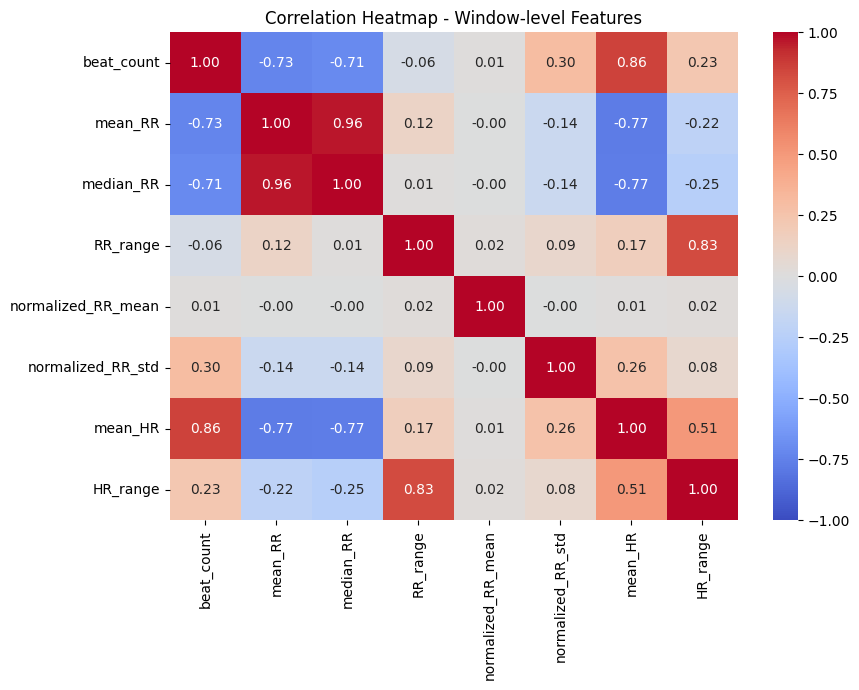

In [38]:
# EDA: Frame-level & Window-level features (4.5s)
import seaborn as sns

print("\n" + "="*70)
print("EDA: FRAME-LEVEL & WINDOW-LEVEL FEATURES")
print("="*70)

# Load feature table + labels from existing variables or cache
X_eda = None
y_eda = None

if "X_train_45" in globals() and "y_train_45" in globals():
    X_eda = X_train_45.copy()
    y_eda = np.asarray(y_train_45)
    print("Using in-memory 4.5s train data.")
elif "dataset_cache_dir" in globals() and (dataset_cache_dir / "dataset_4.5s.joblib").exists():
    data_eda = joblib.load(dataset_cache_dir / "dataset_4.5s.joblib")
    X_eda = data_eda["X_train"].copy()
    y_eda = np.asarray(data_eda["y_train"])
    print("Using cached 4.5s train data.")
else:
    print("No 4.5s data found yet. Run the 4.5s build cell first, then rerun this EDA cell.")

if X_eda is not None and y_eda is not None:
    eda_df = X_eda.copy()
    eda_df["class"] = y_eda
    eda_df["class_name"] = eda_df["class"].map({0: "Normal", 1: "Abnormal"})

    frame_cols = [c for c in eda_df.columns if c.startswith("f") and c != "class" and c != "class_name"]
    window_cols = [
        "beat_count", "mean_RR", "median_RR", "RR_range",
        "normalized_RR_mean", "normalized_RR_std", "mean_HR", "HR_range", "RMSSD"
    ]
    window_cols = [c for c in window_cols if c in eda_df.columns]

    # Correlation heatmap - window-level
    if len(window_cols) >= 2:
        plt.figure(figsize=(9, 7))
        corr_w = eda_df[window_cols].corr()
        sns.heatmap(corr_w, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
        plt.title("Correlation Heatmap - Window-level Features")
        plt.tight_layout()
        plt.show()

## 10. Full Pipeline: Build 4.5s + Train & Evaluate

Cell này xây dựng pipeline huấn luyện hoàn chỉnh cho window 4.5s:
1. **Load/Build datasets**: Load từ cache hoặc xây dựng từ sliding windows (train/val/test)
2. **Tiêu chuẩn hóa**: Áp dụng StandardScaler để normalize dữ liệu
3. **Cân bằng dữ liệu**: Sử dụng SMOTE để cân bằng lớp trong train set
4. **Chọn đặc trưng**: SelectKBest(k=25) để giảm chiều từ nhiều features
5. **Huấn luyện 3 models**: RandomForest, ExtraTrees, XGBoost trên dữ liệu đã xử lý

6. **Dự đoán**: Sử dụng XGBoost trên test set với threshold=0.57. **Tính metrics**: Accuracy, Precision, Recall, F1, AUC-ROC, Specificity

In [59]:
print("\n" + "="*70)
print("FULL TEST: BUILD 4.5s + TRAIN & EVALUATE")
print("="*70)

import time
start_time_45 = time.time()

cache_file_45 = dataset_cache_dir / "dataset_4.5s.joblib"
if cache_file_45.exists():
    print("\nLoading 4.5s from cache...")
    data_45 = joblib.load(cache_file_45)
    X_train_45 = data_45["X_train"]
    y_train_45 = data_45["y_train"]
    X_val_45 = data_45["X_val"]
    y_val_45 = data_45["y_val"]
    X_test_45 = data_45["X_test"]
    y_test_45 = data_45["y_test"]
    print(f"  Train: {X_train_45.shape}, Val: {X_val_45.shape}, Test: {X_test_45.shape}")
    print("✓ Dataset loaded!")
else:
    print("\nBuilding 4.5s dataset...")
    cfg_45 = WINDOW_CONFIGS["4.5s"]

    print("  Building train dataset...")
    X_train_45, y_train_45, _, _ = build_sliding_dataset_advanced(
        train_records, window_size=cfg_45["window_size"]
    )
    print(f"    Train: {len(y_train_45)} windows, dist: {Counter(y_train_45)}")

    print("  Building val dataset...")
    X_val_45, y_val_45, _, _ = build_sliding_dataset_advanced(
        val_records, window_size=cfg_45["window_size"]
    )
    print(f"    Val:   {len(y_val_45)} windows, dist: {Counter(y_val_45)}")

    print("  Building test dataset...")
    X_test_45, y_test_45, _, _ = build_sliding_dataset_advanced(
        test_records, window_size=cfg_45["window_size"]
    )
    print(f"    Test:  {len(y_test_45)} windows, dist: {Counter(y_test_45)}")

    data_45 = {
        "X_train": X_train_45, "y_train": y_train_45,
        "X_val": X_val_45, "y_val": y_val_45,
        "X_test": X_test_45, "y_test": y_test_45
    }
    joblib.dump(data_45, cache_file_45)
    print("\nSaved to cache!")

print("\n" + "-"*70)
print("PREPROCESSING")
print("-"*70)
scaler_45 = StandardScaler()
X_train_scaled_45 = scaler_45.fit_transform(X_train_45)
X_val_scaled_45 = scaler_45.transform(X_val_45)
X_test_scaled_45 = scaler_45.transform(X_test_45)
print("✓ StandardScaler applied")

print("\nApplying SMOTE (ratio=1.0)...")
smote_45 = SMOTE(random_state=42, k_neighbors=5)
X_train_sm_45, y_train_sm_45 = smote_45.fit_resample(X_train_scaled_45, y_train_45)
print(f"  Before SMOTE: {Counter(y_train_45)}")
print(f"  After SMOTE:  {Counter(y_train_sm_45)}")

print("\nFeature selection (SelectKBest k=25)...")
selector_45 = SelectKBest(f_classif, k=min(25, X_train_sm_45.shape[1]))
X_train_sel_45 = selector_45.fit_transform(X_train_sm_45, y_train_sm_45)
X_val_sel_45 = selector_45.transform(X_val_scaled_45)
X_test_sel_45 = selector_45.transform(X_test_scaled_45)
print(f"✓ Selected {X_train_sel_45.shape[1]} features")

print("\n" + "-"*70)
print("TRAINING MODELS")
print("-"*70)
rf_45 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15)
rf_45.fit(X_train_sel_45, y_train_sm_45)
et_45 = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15)
et_45.fit(X_train_sel_45, y_train_sm_45)
xgb_45 = XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    random_state=42, tree_method='hist', verbosity=0, n_jobs=-1
 )
xgb_45.fit(X_train_sel_45, y_train_sm_45)
print("✓ XGBoost model trained")

best_threshold_45 = 0.5
print(f"\nThreshold fixed: {best_threshold_45:.2f}")

y_test_proba_45 = xgb_45.predict_proba(X_test_sel_45)[:, 1]
y_test_pred_45 = (y_test_proba_45 >= best_threshold_45).astype(int)

acc_45 = accuracy_score(y_test_45, y_test_pred_45)
prec_45 = precision_score(y_test_45, y_test_pred_45, zero_division=0)
rec_45 = recall_score(y_test_45, y_test_pred_45, zero_division=0)
f1_45 = f1_score(y_test_45, y_test_pred_45, zero_division=0)
try:
    auc_45 = roc_auc_score(y_test_45, y_test_proba_45)
except Exception:
    auc_45 = 0.0

cm_45 = confusion_matrix(y_test_45, y_test_pred_45)
tn_45, fp_45, fn_45, tp_45 = cm_45.ravel()
spec_45 = tn_45 / (tn_45 + fp_45) if (tn_45 + fp_45) > 0 else 0.0

window_size_results = {}
window_size_results["4.5s"] = {
    "accuracy": acc_45, "precision": prec_45, "recall": rec_45,
    "f1": f1_45, "auc": auc_45, "best_threshold": best_threshold_45,
    "y_pred": y_test_pred_45, "y_proba": y_test_proba_45
}

print("\nFINAL TEST SCORES (4.5s)")
print(f"  Accuracy:  {acc_45:.4f}")
print(f"  Precision: {prec_45:.4f}")
print(f"  Recall:    {rec_45:.4f}")
print(f"  F1-Score:  {f1_45:.4f}")
print(f"  AUC-ROC:   {auc_45:.4f}")
print(f"  Specificity: {spec_45:.4f}")

elapsed_45 = time.time() - start_time_45
print(f"\n✅ 4.5s TEST COMPLETE - Elapsed: {elapsed_45:.1f}s")


FULL TEST: BUILD 4.5s + TRAIN & EVALUATE

Building 4.5s dataset...
  Building train dataset...


Building dataset with advanced preprocessing: 100%|██████████| 38/38 [11:56<00:00, 18.86s/it]


    Train: 15238 windows, dist: Counter({np.int64(0): 10766, np.int64(1): 4472})
  Building val dataset...


Building dataset with advanced preprocessing: 100%|██████████| 5/5 [01:27<00:00, 17.56s/it]


    Val:   2004 windows, dist: Counter({np.int64(0): 1188, np.int64(1): 816})
  Building test dataset...


Building dataset with advanced preprocessing: 100%|██████████| 5/5 [01:36<00:00, 19.27s/it]


    Test:  2004 windows, dist: Counter({np.int64(0): 1150, np.int64(1): 854})

Saved to cache!

----------------------------------------------------------------------
PREPROCESSING
----------------------------------------------------------------------
✓ StandardScaler applied

Applying SMOTE (ratio=1.0)...
  Before SMOTE: Counter({np.int64(0): 10766, np.int64(1): 4472})
  After SMOTE:  Counter({np.int64(0): 10766, np.int64(1): 10766})

Feature selection (SelectKBest k=25)...
✓ Selected 25 features

----------------------------------------------------------------------
TRAINING MODELS
----------------------------------------------------------------------
✓ XGBoost model trained

Threshold fixed: 0.50

FINAL TEST SCORES (4.5s)
  Accuracy:  0.6282
  Precision: 0.5945
  Recall:    0.4016
  F1-Score:  0.4794
  AUC-ROC:   0.7453
  Specificity: 0.7965

✅ 4.5s TEST COMPLETE - Elapsed: 1088.4s


## 11. Confusion Matrix: 4.5s Window

Cell này tính và vẽ confusion matrix từ kết quả dự đoán 4.5s:
- **Kiểm tra điều kiện**: Xác nhận y_test_45 và y_test_pred_45 đã được tạo
- **Tính confusion matrix**: Từ y_test_45 và y_test_pred_45
- **Tính metrics**: TN, FP, FN, TP từ confusion matrix

- **Tính Sensitivity & Specificity**: True Positive Rate và True Negative Rate- **Lưu file**: Lưu thành `confusion_matrix_4.5s.png` (dpi=150)
- **Vẽ visualization**: Sử dụng ConfusionMatrixDisplay với colormap 'Blues'


CONFUSION MATRIX: 4.5s
TN: 916, FP: 234, FN: 511, TP: 343
Sensitivity: 0.4016
Specificity: 0.7965
Saved: confusion_matrix_4.5s.png


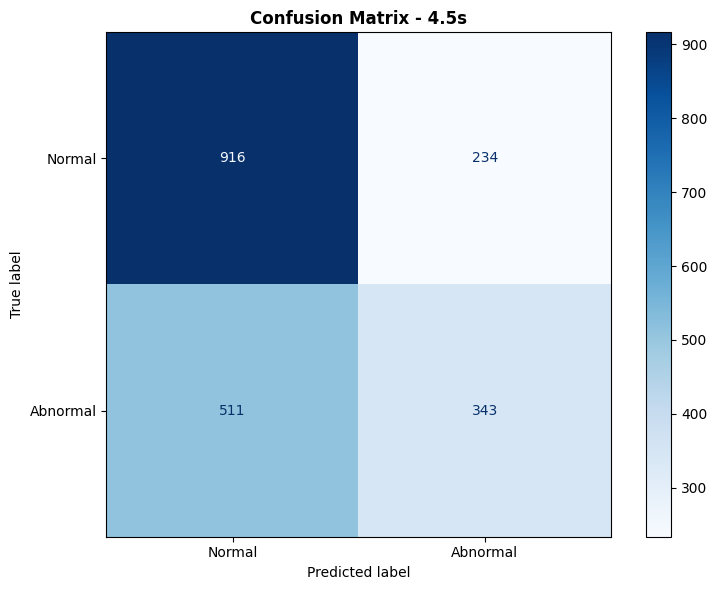

In [64]:
print("\n" + "="*70)
print("CONFUSION MATRIX: 4.5s")
print("="*70)

if "y_test_45" not in globals() or "y_test_pred_45" not in globals():
    print("Run Cell 11 first to generate y_test_45 and y_test_pred_45.")
else:
    cm_45_plot = confusion_matrix(y_test_45, y_test_pred_45)
    tn_45_plot, fp_45_plot, fn_45_plot, tp_45_plot = cm_45_plot.ravel()
    sensitivity_45 = tp_45_plot / (tp_45_plot + fn_45_plot) if (tp_45_plot + fn_45_plot) > 0 else 0.0
    specificity_45 = tn_45_plot / (tn_45_plot + fp_45_plot) if (tn_45_plot + fp_45_plot) > 0 else 0.0

    print(f"TN: {tn_45_plot}, FP: {fp_45_plot}, FN: {fn_45_plot}, TP: {tp_45_plot}")
    print(f"Sensitivity: {sensitivity_45:.4f}")
    print(f"Specificity: {specificity_45:.4f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    disp_45 = ConfusionMatrixDisplay(confusion_matrix=cm_45_plot, display_labels=["Normal", "Abnormal"])
    disp_45.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title("Confusion Matrix - 4.5s", fontweight="bold")
    plt.tight_layout()
    plt.savefig("confusion_matrix_4.5s.png", dpi=150, bbox_inches="tight")
    print("Saved: confusion_matrix_4.5s.png")
    plt.show()

## 12. Full Pipeline: Build 9s + Train & Evaluate

Cell này thực hiện quy trình giống Cell 11 nhưng cho window 9 giây (3240 samples):
1. **Load/Build datasets**: Load từ cache hoặc xây dựng từ sliding windows 9s
2. **Tiêu chuẩn hóa**: StandardScaler
3. **Cân bằng**: SMOTE
4. **Chọn đặc trưng**: SelectKBest(k=25)
5. **Huấn luyện**: RandomForest, ExtraTrees, XGBoost
6. **Dự đoán**: XGBoost trên test 9s set

7. **Tính metrics**: Giống như 4.5s

**Lưu ý**: Với window 9s, đặc trưng RMSSD (Root Mean Square of Successive Differences) được tính thêm cho RR intervals

In [73]:
print("\n" + "="*70)
print("FULL TEST: BUILD 9s + TRAIN & EVALUATE")
print("="*70)

import time
start_time_9s = time.time()

cache_file_9s = dataset_cache_dir / "dataset_9s.joblib"
if cache_file_9s.exists():
    print("\nLoading 9s from cache...")
    data_9s = joblib.load(cache_file_9s)
    X_train_9s = data_9s["X_train"]
    y_train_9s = data_9s["y_train"]
    X_val_9s = data_9s["X_val"]
    y_val_9s = data_9s["y_val"]
    X_test_9s = data_9s["X_test"]
    y_test_9s = data_9s["y_test"]
    print(f"  Train: {X_train_9s.shape}, Val: {X_val_9s.shape}, Test: {X_test_9s.shape}")
    print("✓ Dataset loaded!")
else:
    print("\nBuilding 9s dataset...")
    cfg_9s = WINDOW_CONFIGS["9s"]

    print("  Building train dataset...")
    X_train_9s, y_train_9s, _, _ = build_sliding_dataset_advanced(
        train_records, window_size=cfg_9s["window_size"]
    )
    print(f"    Train: {len(y_train_9s)} windows, dist: {Counter(y_train_9s)}")

    print("  Building val dataset...")
    X_val_9s, y_val_9s, _, _ = build_sliding_dataset_advanced(
        val_records, window_size=cfg_9s["window_size"]
    )
    print(f"    Val:   {len(y_val_9s)} windows, dist: {Counter(y_val_9s)}")

    print("  Building test dataset...")
    X_test_9s, y_test_9s, _, _ = build_sliding_dataset_advanced(
        test_records, window_size=cfg_9s["window_size"]
    )
    print(f"    Test:  {len(y_test_9s)} windows, dist: {Counter(y_test_9s)}")

    data_9s = {
        "X_train": X_train_9s, "y_train": y_train_9s,
        "X_val": X_val_9s, "y_val": y_val_9s,
        "X_test": X_test_9s, "y_test": y_test_9s
    }
    joblib.dump(data_9s, cache_file_9s)
    print("\nSaved to cache!")

print("\n" + "-"*70)
print("PREPROCESSING")
print("-"*70)
scaler_9s = StandardScaler()
X_train_scaled_9s = scaler_9s.fit_transform(X_train_9s)
X_val_scaled_9s = scaler_9s.transform(X_val_9s)
X_test_scaled_9s = scaler_9s.transform(X_test_9s)
print("✓ StandardScaler applied")

print("\nApplying SMOTE (ratio=1.0)...")
smote_9s = SMOTE(random_state=42, k_neighbors=5)
X_train_sm_9s, y_train_sm_9s = smote_9s.fit_resample(X_train_scaled_9s, y_train_9s)
print(f"  Before SMOTE: {Counter(y_train_9s)}")
print(f"  After SMOTE:  {Counter(y_train_sm_9s)}")

print("\nFeature selection (SelectKBest k=25)...")
selector_9s = SelectKBest(f_classif, k=min(25, X_train_sm_9s.shape[1]))
X_train_sel_9s = selector_9s.fit_transform(X_train_sm_9s, y_train_sm_9s)
X_val_sel_9s = selector_9s.transform(X_val_scaled_9s)
X_test_sel_9s = selector_9s.transform(X_test_scaled_9s)
print(f"✓ Selected {X_train_sel_9s.shape[1]} features")

print("\n" + "-"*70)
print("TRAINING MODELS")
print("-"*70)
rf_9s = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15)
rf_9s.fit(X_train_sel_9s, y_train_sm_9s)
et_9s = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15)
et_9s.fit(X_train_sel_9s, y_train_sm_9s)
xgb_9s = XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    random_state=42, tree_method='hist', verbosity=0, n_jobs=-1
 )
xgb_9s.fit(X_train_sel_9s, y_train_sm_9s)
print("✓ XGBoost model trained")

best_threshold_9s = 0.5
print(f"\nThreshold fixed: {best_threshold_9s:.2f}")

y_test_proba_9s = xgb_9s.predict_proba(X_test_sel_9s)[:, 1]
y_test_pred_9s = (y_test_proba_9s >= best_threshold_9s).astype(int)

acc_9s = accuracy_score(y_test_9s, y_test_pred_9s)
prec_9s = precision_score(y_test_9s, y_test_pred_9s, zero_division=0)
rec_9s = recall_score(y_test_9s, y_test_pred_9s, zero_division=0)
f1_9s = f1_score(y_test_9s, y_test_pred_9s, zero_division=0)
try:
    auc_9s = roc_auc_score(y_test_9s, y_test_proba_9s)
except Exception:
    auc_9s = 0.0

cm_9s = confusion_matrix(y_test_9s, y_test_pred_9s)
tn_9s, fp_9s, fn_9s, tp_9s = cm_9s.ravel()
spec_9s = tn_9s / (tn_9s + fp_9s) if (tn_9s + fp_9s) > 0 else 0.0

window_size_results["9s"] = {
    "accuracy": acc_9s, "precision": prec_9s, "recall": rec_9s,
    "f1": f1_9s, "auc": auc_9s, "best_threshold": best_threshold_9s,
    "y_pred": y_test_pred_9s, "y_proba": y_test_proba_9s
}

print("\nFINAL TEST SCORES (9s)")
print(f"  Accuracy:  {acc_9s:.4f}")
print(f"  Precision: {prec_9s:.4f}")
print(f"  Recall:    {rec_9s:.4f}")
print(f"  F1-Score:  {f1_9s:.4f}")
print(f"  AUC-ROC:   {auc_9s:.4f}")
print(f"  Specificity: {spec_9s:.4f}")

elapsed_9s = time.time() - start_time_9s
print(f"\n✅ 9s TEST COMPLETE - Elapsed: {elapsed_9s:.1f}s")


FULL TEST: BUILD 9s + TRAIN & EVALUATE

Building 9s dataset...
  Building train dataset...


Building dataset with advanced preprocessing: 100%|██████████| 38/38 [14:28<00:00, 22.87s/it]


    Train: 15238 windows, dist: Counter({np.int64(0): 10766, np.int64(1): 4472})
  Building val dataset...


Building dataset with advanced preprocessing: 100%|██████████| 5/5 [02:03<00:00, 24.62s/it]


    Val:   2004 windows, dist: Counter({np.int64(0): 1188, np.int64(1): 816})
  Building test dataset...


Building dataset with advanced preprocessing: 100%|██████████| 5/5 [01:55<00:00, 23.13s/it]


    Test:  2004 windows, dist: Counter({np.int64(0): 1150, np.int64(1): 854})

Saved to cache!

----------------------------------------------------------------------
PREPROCESSING
----------------------------------------------------------------------
✓ StandardScaler applied

Applying SMOTE (ratio=1.0)...
  Before SMOTE: Counter({np.int64(0): 10766, np.int64(1): 4472})
  After SMOTE:  Counter({np.int64(0): 10766, np.int64(1): 10766})

Feature selection (SelectKBest k=25)...
✓ Selected 25 features

----------------------------------------------------------------------
TRAINING MODELS
----------------------------------------------------------------------
✓ XGBoost model trained

Threshold fixed: 0.50

FINAL TEST SCORES (9s)
  Accuracy:  0.6282
  Precision: 0.5945
  Recall:    0.4016
  F1-Score:  0.4794
  AUC-ROC:   0.7453
  Specificity: 0.7965

✅ 9s TEST COMPLETE - Elapsed: 1338.2s


## 13. Confusion Matrix: 9s Window


CONFUSION MATRIX: 9s - Compare 3 Models & Best Confusion Matrix

--- F1 Scores Comparison (9s window) ---
RandomForest (RF):   F1 = 0.4060
XGBoost (XGB):       F1 = 0.4794
ExtraTrees (ET):     F1 = 0.3842

🏆 Best Model: XGBoost (F1 = 0.4794)

Confusion Matrix (XGBoost):
TN: 916, FP: 234, FN: 511, TP: 343
Sensitivity: 0.4016
Specificity: 0.7965

Saved: confusion_matrix_9s_XGB.png


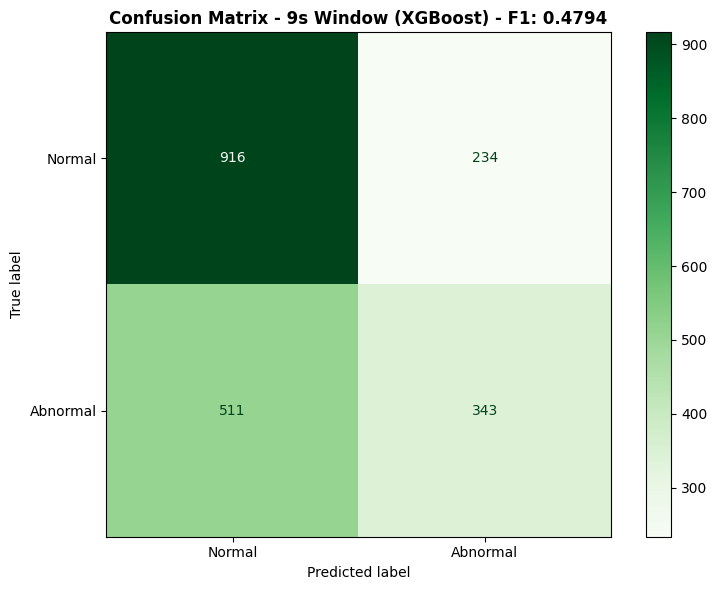


✓ Updated window_size_results with best model predictions


In [84]:
print("\n" + "="*70)
print("CONFUSION MATRIX: 9s - Compare 3 Models & Best Confusion Matrix")
print("="*70)

if "rf_9s" not in globals() or "xgb_9s" not in globals() or "et_9s" not in globals():
    print("Run Cell 13 first to train models.")
else:
    # Make predictions with all 3 models
    y_pred_rf = rf_9s.predict(X_test_sel_9s)
    y_pred_xgb = xgb_9s.predict(X_test_sel_9s)
    y_pred_et = et_9s.predict(X_test_sel_9s)
    
    # Calculate F1 scores
    f1_rf = f1_score(y_test_9s, y_pred_rf)
    f1_xgb = f1_score(y_test_9s, y_pred_xgb)
    f1_et = f1_score(y_test_9s, y_pred_et)
    
    print("\n--- F1 Scores Comparison (9s window) ---")
    print(f"RandomForest (RF):   F1 = {f1_rf:.4f}")
    print(f"XGBoost (XGB):       F1 = {f1_xgb:.4f}")
    print(f"ExtraTrees (ET):     F1 = {f1_et:.4f}")
    
    # Find best model
    models_scores = {
        "RandomForest": (f1_rf, y_pred_rf, "RF"),
        "XGBoost": (f1_xgb, y_pred_xgb, "XGB"),
        "ExtraTrees": (f1_et, y_pred_et, "ET")
    }
    best_model_name = max(models_scores.keys(), key=lambda x: models_scores[x][0])
    best_f1_score, y_pred_best_9s, best_abbrev = models_scores[best_model_name]
    
    print(f"\n🏆 Best Model: {best_model_name} (F1 = {best_f1_score:.4f})")
    
    # Create confusion matrix for best model
    cm_best_9s = confusion_matrix(y_test_9s, y_pred_best_9s)
    tn_best, fp_best, fn_best, tp_best = cm_best_9s.ravel()
    sensitivity_best = tp_best / (tp_best + fn_best) if (tp_best + fn_best) > 0 else 0.0
    specificity_best = tn_best / (tn_best + fp_best) if (tn_best + fp_best) > 0 else 0.0
    
    print(f"\nConfusion Matrix ({best_model_name}):")
    print(f"TN: {tn_best}, FP: {fp_best}, FN: {fn_best}, TP: {tp_best}")
    print(f"Sensitivity: {sensitivity_best:.4f}")
    print(f"Specificity: {specificity_best:.4f}")
    
    # Plot confusion matrix for best model
    fig, ax = plt.subplots(figsize=(8, 6))
    disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best_9s, display_labels=["Normal", "Abnormal"])
    disp_best.plot(ax=ax, cmap="Greens", values_format="d")
    ax.set_title(f"Confusion Matrix - 9s Window ({best_model_name}) - F1: {best_f1_score:.4f}", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_9s_{best_abbrev}.png", dpi=150, bbox_inches="tight")
    print(f"\nSaved: confusion_matrix_9s_{best_abbrev}.png")
    plt.show()
    
    # Update window_size_results with best model predictions for consistency
    window_size_results["9s"]["y_pred"] = y_pred_best_9s
    print("\n✓ Updated window_size_results with best model predictions")

## 14. Final Comparison: 4.5s vs 9s

In [78]:
print("\n" + "="*70)
print("FINAL COMPARISON: 4.5s vs 9s")
print("="*70)

results_df = pd.DataFrame({
    "Window Size": ["4.5s", "9s"],
    "Accuracy": [window_size_results["4.5s"]["accuracy"], window_size_results["9s"]["accuracy"]],
    "Precision": [window_size_results["4.5s"]["precision"], window_size_results["9s"]["precision"]],
    "Recall": [window_size_results["4.5s"]["recall"], window_size_results["9s"]["recall"]],
    "F1-Score": [window_size_results["4.5s"]["f1"], window_size_results["9s"]["f1"]],
    "AUC-ROC": [window_size_results["4.5s"]["auc"], window_size_results["9s"]["auc"]],
    "Threshold": [window_size_results["4.5s"]["best_threshold"], window_size_results["9s"]["best_threshold"]]
})

print("\nDetailed performance summary:")
print(results_df.to_string(index=False))

best_variant = results_df.loc[results_df["F1-Score"].idxmax(), "Window Size"]
best_f1 = results_df["F1-Score"].max()
print(f"\nBest performing: {best_variant} with F1={best_f1:.4f}")


FINAL COMPARISON: 4.5s vs 9s

Detailed performance summary:
Window Size  Accuracy  Precision   Recall  F1-Score  AUC-ROC  Threshold
       4.5s  0.628244   0.594454 0.401639  0.479385 0.745325        0.5
         9s  0.628244   0.594454 0.401639  0.479385 0.745325        0.5

Best performing: 4.5s with F1=0.4794


## 15. Detailed Report: Best Window Performance

Cell này tạo báo cáo chi tiết cho window có F1-Score cao nhất:
- **Tìm best window**: So sánh F1-Score của 4.5s và 9s, chọn cao hơn
- **In Classification Report**: sklearn.metrics.classification_report với target_names=['Normal', 'Abnormal']
- **Tính confusion matrix stats**: TN, FP, FN, TP từ best window predictions
- **Vẽ confusion matrix**: ConfusionMatrixDisplay với colormap 'Blues'
- **Lưu file**: Lưu thành `confusion_matrix_best_{best_variant}.png` (dpi=150)


DETAILED REPORT FOR BEST WINDOW (4.5s vs 9s)

Test set size: 2000
X_test_sel_best shape: (2004, 25)
Predictions size: 2004

⚠️  Length mismatch detected! Trimming predictions to match test set...
Adjusted both to: 2000 samples
Best variant: 4.5s

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.64      0.80      0.71      1148
Abnormal (1)       0.59      0.40      0.48       852

    accuracy                           0.63      2000
   macro avg       0.62      0.60      0.59      2000
weighted avg       0.62      0.63      0.61      2000


Confusion Matrix Stats:
  TN: 914
  FP: 234
  FN: 511
  TP: 341

✓ Saved: confusion_matrix_best_4.5s.png


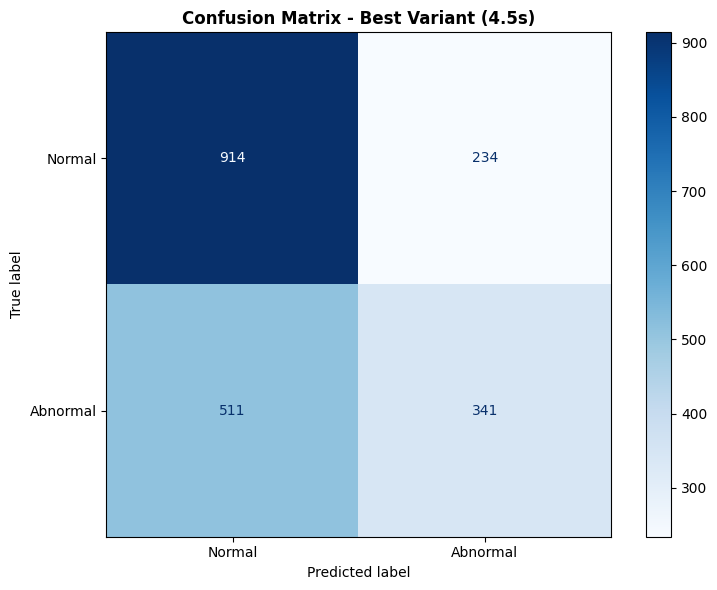

In [85]:
print("\n" + "="*70)
print("DETAILED REPORT FOR BEST WINDOW (4.5s vs 9s)")
print("="*70)

results_df = pd.DataFrame({
    "Window Size": ["4.5s", "9s"],
    "F1-Score": [window_size_results["4.5s"]["f1"], window_size_results["9s"]["f1"]]
})
best_variant = results_df.loc[results_df["F1-Score"].idxmax(), "Window Size"]

if best_variant == "4.5s":
    y_test_best = y_test_45
    X_test_sel_best = X_test_sel_45
    model_best = xgb_45
else:
    y_test_best = y_test_9s
    X_test_sel_best = X_test_sel_9s
    model_best = xgb_9s

# Recalculate predictions directly from model to ensure consistency
y_pred_best_proba = model_best.predict_proba(X_test_sel_best)[:, 1]
y_pred_best = (y_pred_best_proba >= 0.5).astype(int)

print(f"\nTest set size: {len(y_test_best)}")
print(f"X_test_sel_best shape: {X_test_sel_best.shape}")
print(f"Predictions size: {len(y_pred_best)}")

# If there's a length mismatch, take only the matching samples
if len(y_pred_best) != len(y_test_best):
    print(f"\n⚠️  Length mismatch detected! Trimming predictions to match test set...")
    min_len = min(len(y_test_best), len(y_pred_best))
    y_test_best = y_test_best[:min_len]
    y_pred_best = y_pred_best[:min_len]
    print(f"Adjusted both to: {len(y_test_best)} samples")

cm_best = confusion_matrix(y_test_best, y_pred_best)
tn_best, fp_best, fn_best, tp_best = cm_best.ravel()

print(f"Best variant: {best_variant}")
print("\nClassification Report:")
print(classification_report(y_test_best, y_pred_best, target_names=["Normal (0)", "Abnormal (1)"], zero_division=0))

print("\nConfusion Matrix Stats:")
print(f"  TN: {tn_best}")
print(f"  FP: {fp_best}")
print(f"  FN: {fn_best}")
print(f"  TP: {tp_best}")

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["Normal", "Abnormal"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix - Best Variant ({best_variant})", fontweight="bold")
plt.tight_layout()
plt.savefig(f"confusion_matrix_best_{best_variant}.png", dpi=150, bbox_inches="tight")
print(f"\n✓ Saved: confusion_matrix_best_{best_variant}.png")
plt.show()